# Podcast Listening Time Prediction

<a id="introduction"></a>
## Introduction

I have started working on this project to expand my skill set by doing a comprehensive project.

Find more details on the problem statement [here](https://www.kaggle.com/competitions/playground-series-s5e4).

First, I performed comprehensive exploratory data analysis to understand relationships among the most important variables and detect potential issues such as sknewness, outliers and missing values. Then, I handled these issues, cleansed the data and performed feature engineering. Lastly, I built machine learning models to predict podcast listening time.

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

%matplotlib inline
sns.set_style('darkgrid')

#### Read train and test data

In [2]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

#### Describe data

In [3]:
print("Train data's size: ", train_data.shape)
print("Test data's size: ", test_data.shape)

Train data's size:  (750000, 12)
Test data's size:  (250000, 11)


In [4]:
# Identify numerical columns by excluding object type columns
numCols = list(train_data.select_dtypes(exclude='object').columns)

# Remove "id" from the numerical columns as it is not a feature
numCols.remove("id")
print(f"There are {len(numCols)} numerical features:\n", numCols)

There are 5 numerical features:
 ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads', 'Listening_Time_minutes']


In [5]:
# Identify categorical columns by including only object type columns
catCols = list(train_data.select_dtypes(include='object').columns)

# Print the number of categorical features and their names
print(f"There are {len(catCols)} categorical features:\n", catCols)

There are 6 categorical features:
 ['Podcast_Name', 'Episode_Title', 'Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']


In [6]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [7]:
train_data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [8]:
train_data.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


<a name="eda"></a>
## Exploratory Data Analysis

<a id="listen-time"></a>
### Listening Time

In [9]:
plot_data = train_data.copy()

# Extract the episode number from the "Episode_Title" column and convert it to an integer
plot_data["Episode_No"] = plot_data["Episode_Title"].str.split("Episode", expand=True)[1].astype(int)

<Axes: xlabel='Listening_Time_minutes', ylabel='Count'>

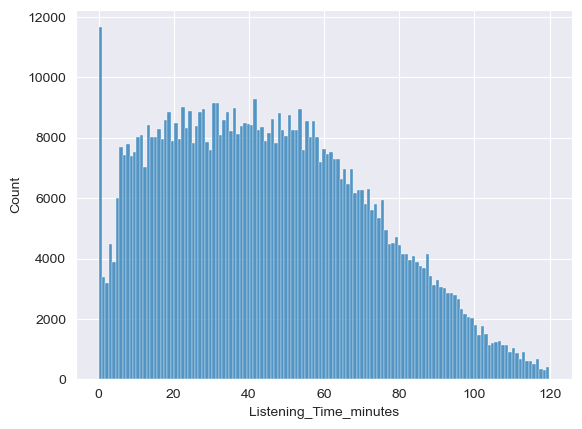

In [10]:
sns.histplot(plot_data, x="Listening_Time_minutes")

<a name="numerical"></a>
### Numerical Features

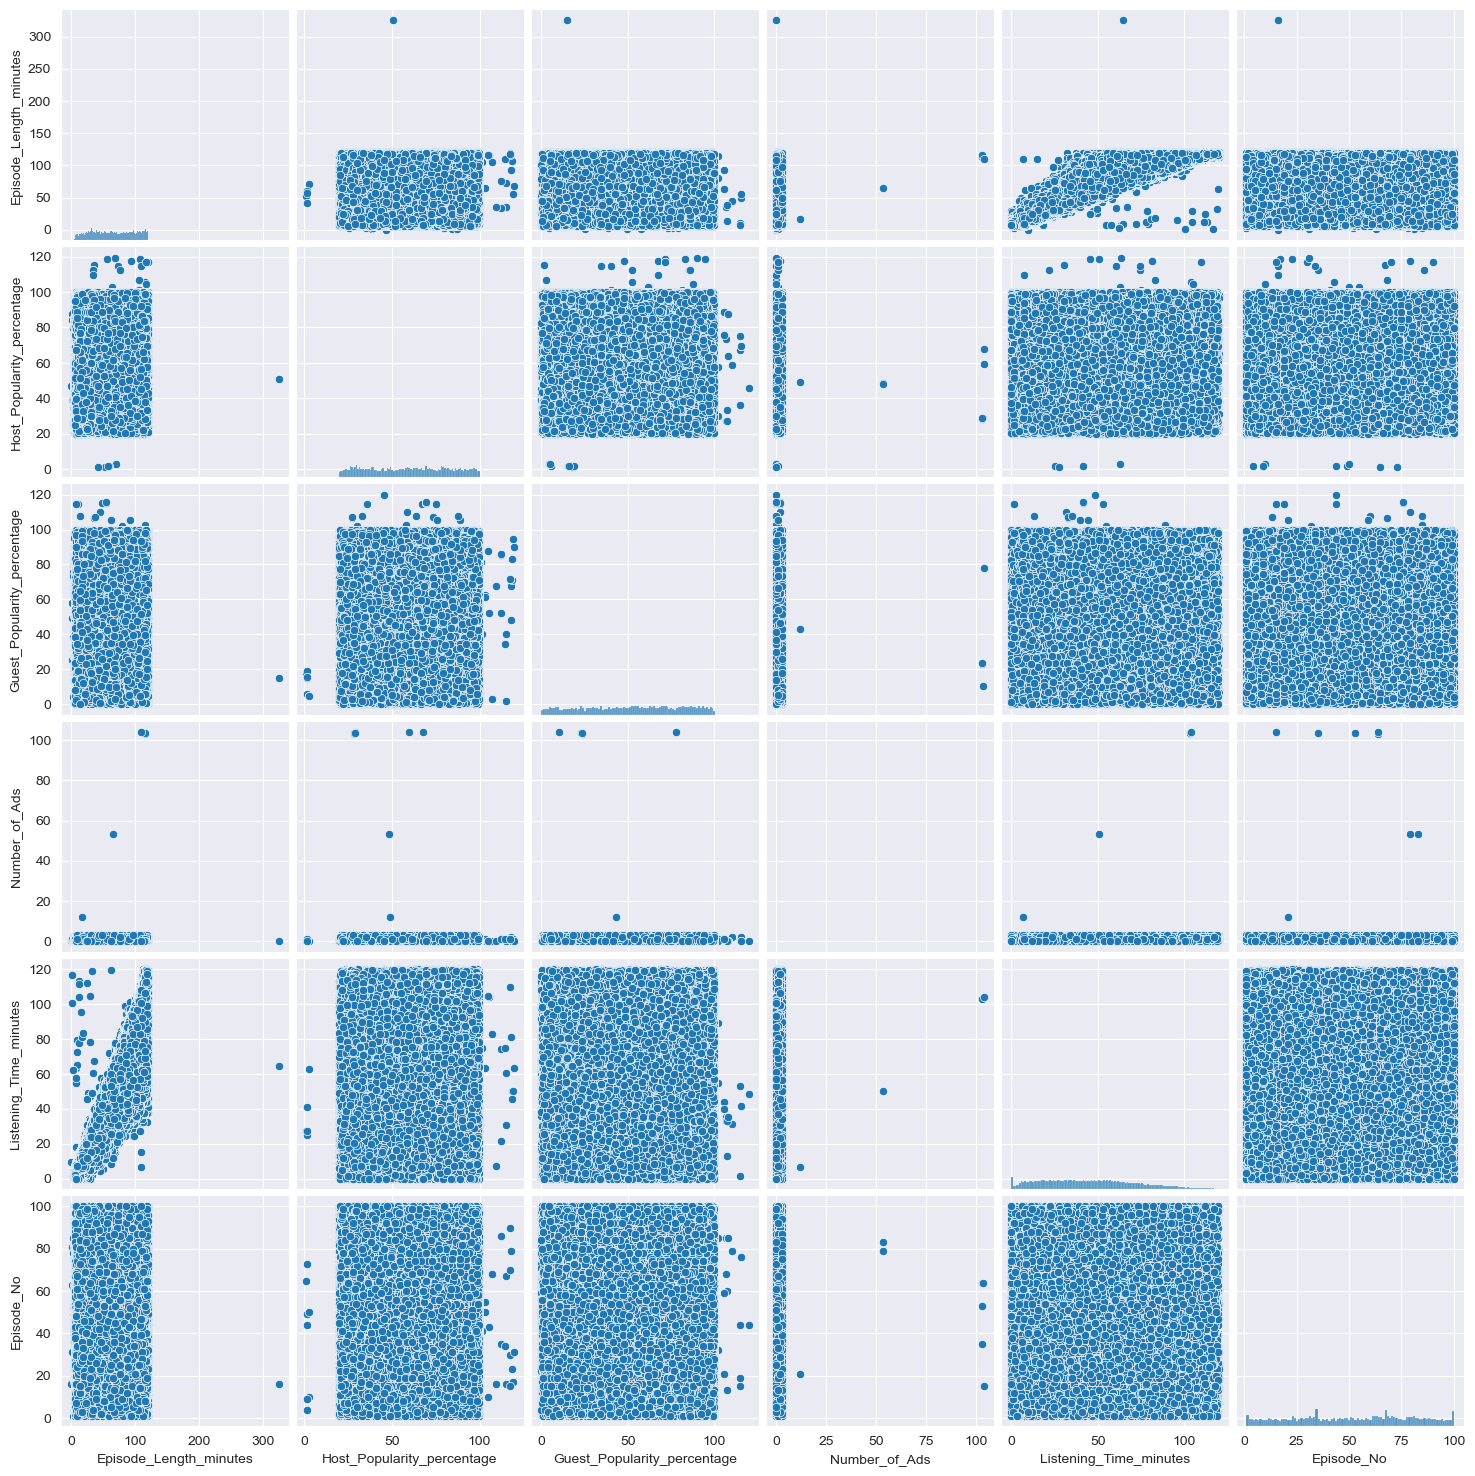

In [11]:
sns.pairplot(plot_data[numCols + ["Episode_No"]])

<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

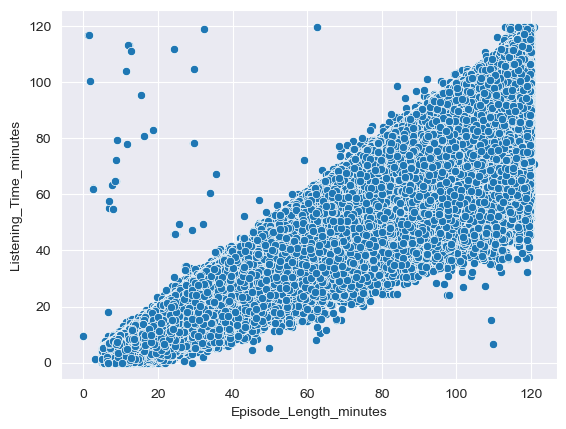

In [12]:
sns.scatterplot(plot_data[plot_data["Episode_Length_minutes"].lt(200)], x="Episode_Length_minutes", y="Listening_Time_minutes")

In [13]:
plot_data.groupby("Publication_Day")[["Episode_Length_minutes", "Listening_Time_minutes"]].agg(['min', 'max', "mean", "count"])

Episode_Length_minutes                             \
                                   min     max       mean   count   
Publication_Day                                                     
Friday                            0.00  120.93  63.987517   96088   
Monday                            2.47  119.99  65.180966   99215   
Saturday                          2.47  120.64  64.167475   91442   
Sunday                            5.00  119.98  63.972644  102794   
Thursday                          1.24  120.64  63.602380   91794   
Tuesday                           5.00  325.24  65.765078   86247   
Wednesday                         2.97  119.99  64.948196   95327   

                Listening_Time_minutes                             
                                   min     max       mean   count  
Publication_Day                                                    
Friday                             0.0  119.97  45.206591  108237  
Monday                             0.0  119.97  45.969630  111963  
Saturday                           0.0  119.97  45.326775  103505  
Sunday                             0.0  119.97  44.817398  115946  
Thursday                           0.0  119.97  44.869706  104360  
Tuesday                            0.0  119.97  46.131411   98103  
Wednesday                          0.0  119.97  45.807177  107886

In [14]:
plot_data.groupby("Genre")[["Episode_Length_minutes", "Listening_Time_minutes"]].mean()

,Episode_Length_minutes,Listening_Time_minutes
Genre,,
Business,64.537846,45.538151
Comedy,63.300076,44.426441
Education,64.979055,45.736640
Health,65.294750,45.741413
Lifestyle,64.837087,45.523117
Music,65.991298,46.578394
News,63.720797,44.406144
Sports,64.290514,44.935722
Technology,64.034032,45.634749


<a name="categorical"></a>
### Categorical Features

In [15]:
def print_category_analysis(col_name: pd.Series):
    """
    Prints the value counts of a specified categorical column in the training data.
    Also prints the intersection of unique values between the test and training data for the specified column.

    Parameters:
    col_name (pd.Series): The name of the column to analyze.
    """
    # Print the value counts of the specified column in the training data
    print(train_data[col_name].value_counts().to_string())
    
    # Print the intersection of unique values between the test and training data for the specified column
    print(set(test_data[col_name]) & set(train_data[col_name]))

In [16]:
print_category_analysis("Podcast_Name")

Podcast_Name
Tech Talks             22847
Sports Weekly          20053
Funny Folks            19635
Tech Trends            19549
Fitness First          19488
Business Insights      19480
Style Guide            19364
Game Day               19272
Melody Mix             18889
Criminal Minds         17735
Finance Focus          17628
Detective Diaries      17452
Crime Chronicles       17374
Athlete's Arena        17327
Fashion Forward        17280
Tune Time              17254
Business Briefs        17012
Lifestyle Lounge       16661
True Crime Stories     16373
Sports Central         16191
Digital Digest         16171
Humor Hub              16144
Mystery Matters        16002
Comedy Corner          15927
Joke Junction          15074
Wellness Wave          15009
Sport Spot             14778
Gadget Geek            14770
Home & Living          14686
Laugh Line             14673
Life Lessons           14464
World Watch            14043
Sound Waves            13928
Global News            13649
M

In [17]:
print_category_analysis("Genre")

Genre
Sports        87606
Technology    86256
True Crime    85059
Lifestyle     82461
Comedy        81453
Business      80521
Health        71416
News          63385
Music         62743
Education     49100
{'Sports', 'Comedy', 'News', 'True Crime', 'Business', 'Education', 'Technology', 'Music', 'Health', 'Lifestyle'}


In [18]:
print_category_analysis("Publication_Day")

Publication_Day
Sunday       115946
Monday       111963
Friday       108237
Wednesday    107886
Thursday     104360
Saturday     103505
Tuesday       98103
{'Tuesday', 'Wednesday', 'Monday', 'Saturday', 'Friday', 'Sunday', 'Thursday'}


In [19]:
print_category_analysis("Publication_Time")

Publication_Time
Night        196849
Evening      195778
Afternoon    179460
Morning      177913
{'Night', 'Afternoon', 'Evening', 'Morning'}


In [20]:
print_category_analysis("Episode_Sentiment")

Episode_Sentiment
Neutral     251291
Negative    250116
Positive    248593
{'Positive', 'Neutral', 'Negative'}


<a name="missing"></a>
### Missing Values

Most machine learning algorithms give an error when we train them on data with missing values. Therefore, it's important to identify them before deciding how to handle them (drop features or impute missing value).

In [21]:
missing_data = train_data.isnull().sum()
missing_data_per = missing_data / len(train_data) * 100
missing_data_per

id                              0.000000
Podcast_Name                    0.000000
Episode_Title                   0.000000
Episode_Length_minutes         11.612400
Genre                           0.000000
Host_Popularity_percentage      0.000000
Publication_Day                 0.000000
Publication_Time                0.000000
Guest_Popularity_percentage    19.470667
Number_of_Ads                   0.000133
Episode_Sentiment               0.000000
Listening_Time_minutes          0.000000
dtype: float64

<Axes: xlabel='None', ylabel='None'>

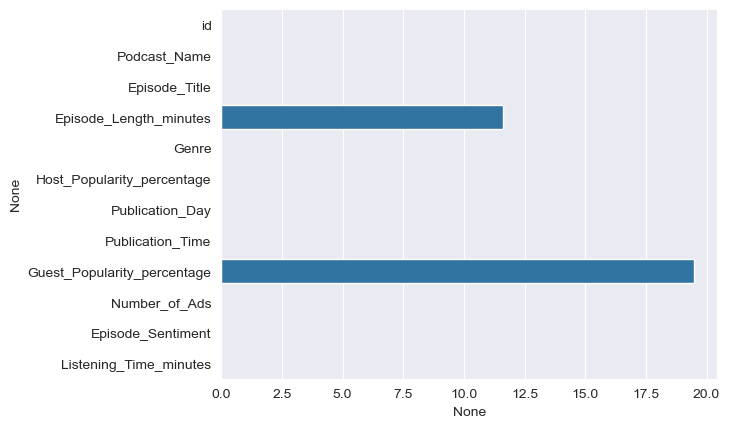

In [22]:
sns.barplot(y=missing_data_per.index,
            x=missing_data_per)

<Axes: title={'center': 'Episode_Length_minutes'}, xlabel='Genre'>

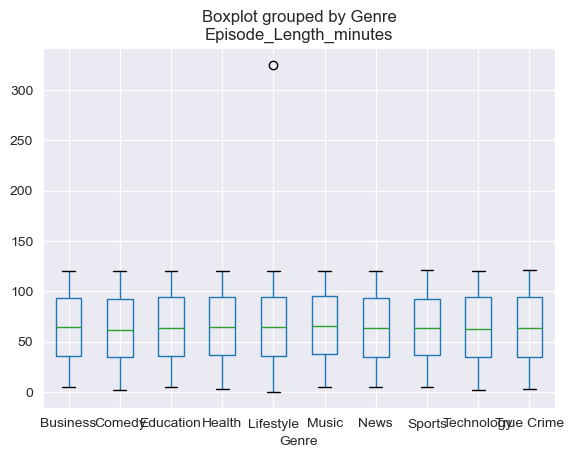

In [23]:
plot_data.boxplot(by ="Genre", column =["Episode_Length_minutes"])

<Axes: title={'center': 'Guest_Popularity_percentage'}, xlabel='Genre'>

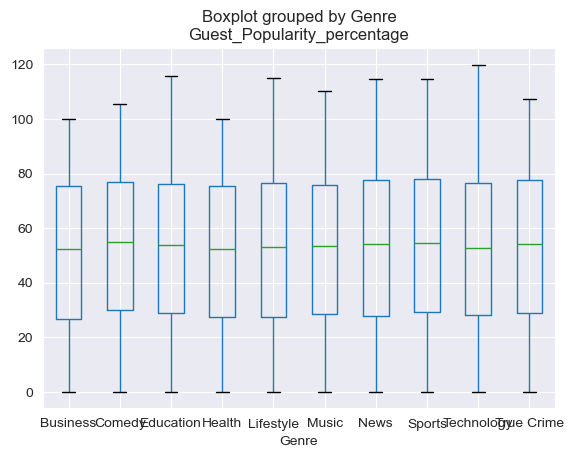

In [24]:
plot_data.boxplot(by ="Genre", column =["Guest_Popularity_percentage"])

array([<Axes: title={'center': 'Episode_Length_minutes'}, xlabel='Episode_Sentiment'>,
       <Axes: title={'center': 'Guest_Popularity_percentage'}, xlabel='Episode_Sentiment'>],
      dtype=object)

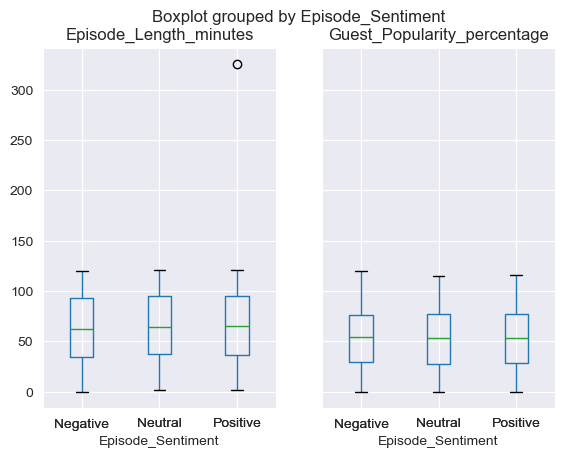

In [25]:
plot_data.boxplot(by ="Episode_Sentiment", column =["Episode_Length_minutes", "Guest_Popularity_percentage"])

<Axes: xlabel='Host_Popularity_percentage', ylabel='Episode_Length_minutes'>

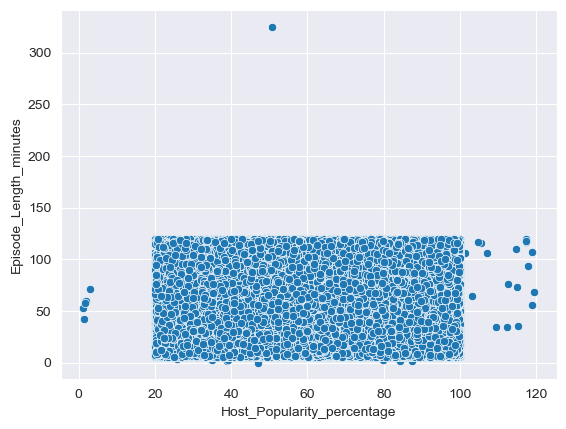

In [26]:
sns.scatterplot(data=plot_data, x="Host_Popularity_percentage", y="Episode_Length_minutes")

<Axes: xlabel='Host_Popularity_percentage', ylabel='Guest_Popularity_percentage'>

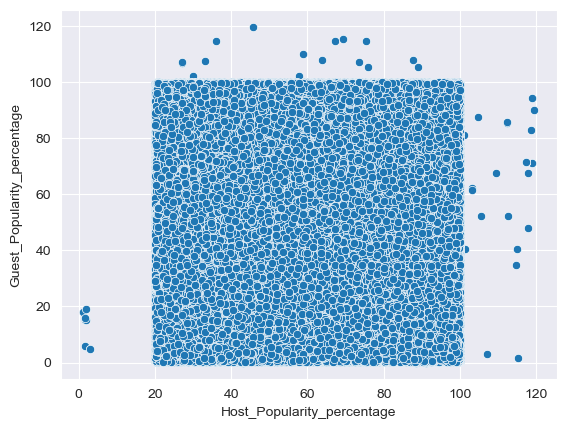

In [27]:
sns.scatterplot(data=plot_data, x="Host_Popularity_percentage", y="Guest_Popularity_percentage")